# 🌍 Étude Santé Publique : Analyse de la Sous-nutrition Mondiale

**Auteur :** Helton Dos Santos Moreira  
**Date :** Mars 2026  
**Client :** FAO (Organisation des Nations Unies pour l'Alimentation et l'Agriculture)

---

## 🎯 Objectif

Analyser les données de sous-nutrition mondiale en 2017 pour répondre à la question : **Le problème de la faim est-il un problème de quantité de nourriture produite, ou de répartition ?**

### 📊 Datasets utilisés

- `population.csv` : Population mondiale par pays (2017)
- `dispo_alimentaire.csv` : Disponibilité alimentaire par pays et par produit
- `aide_alimentaire.csv` : Aide alimentaire reçue par pays (2013-2017)
- `sous_nutrition.csv` : Taux de sous-nutrition par pays

### 🛠️ Technologies

Python 3.9+ • Pandas • Matplotlib • Seaborn

---


**[5. Conclusion et recommandations](#conclusion)**
## 📑 Table des matières

**[1. Configuration et imports](#section1)**
   - [Chargement des librairies](#section1_1)
   - [Importation des datasets FAO](#section1_2)

**[2. Exploration des données](#section2)**
   - [Dataset Population](#section2_1)
   - [Dataset Disponibilité alimentaire](#section2_2)
   - [Dataset Aide alimentaire](#section2_3)
   - [Dataset Sous-nutrition](#section2_3)

**[3. Analyses principales](#section3)**
   - [3.1 - Proportion de personnes en sous nutrition](#section3_1)
   - [3.1 - Proportion de personnes en sous nutrition](#section3_1)
   - [3.2 - Nombre théorique de personne qui pourrait être nourries](#section3_2)
   - [3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux](#section3_3)
   - [3.4 - Utilisation de la disponibilité intérieure](#section3_4)
   - [3.5 - Utilisation des céréales](#section3_5)
   - [3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017](#section3_6)
   - [3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013](#section3_7)
   - [3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016](#section3_8)
   - [3.9 - Pays avec le moins de disponibilité par habitant](#section3_9)
   - [3.10 - Pays avec le plus de disponibilité par habitant](#section3_10)
   - [3.11 - Exemple de la Thaïlande pour le Manioc](#section3_11)

**[4. Analyses complémentaires](#section4)**
   - [Disponibilité par continent](#section6_1)
   - [Corrélation disponibilité vs sous-nutrition](#section6_2)
   - [Apport animal vs végétal](#section6_3)

---

**Environnement de travail :** Python 3.9+ avec Pandas, Matplotlib et Seaborn pour l'analyse et la visualisation des données FAO.


<a id="etape1"></a>

## 1. Configuration et imports


<a id="section1_1"></a>

### Chargement des librairies


In [5]:
#Importation de la librairie Pandas
import pandas as pd

# Configuration des visualisations
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Options d'affichage Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Environnement configuré et prêt pour l'analyse")


<a id="section1_2"></a>

### Importation des datasets FAO


In [7]:
#Importation du fichier population.csv
population = pd.read_csv('data/population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('data/dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('data/aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('data/sous_nutrition.csv')

<a id="etape2"></a>

## 2. Exploration des données


<a id="section2_1"></a>

### Dataset Population


In [10]:
#Afficher les dimensions du dataset
print(f"Le dataset comporte {population.shape[0]} lignes \net {population.shape[1]} colonnes.")

Le dataset comporte 1416 lignes 
et 3 colonnes.


In [11]:
#Consulter le nombre de colonnes
print(f"il y a {len(population.columns)} colonnes dans le fichier \n")

#La nature des données dans chacune des colonnes
print(f"voici la nature de données dans chacune des colonnes :\n")
print(population.dtypes)
print()

#Le nombre de valeurs présentes dans chacune des colonnes
print(f"Le nombre de valeurs présentes dans chacune des colonnes : \n")
population.count()

il y a 3 colonnes dans le fichier 

voici la nature de données dans chacune des colonnes :

Zone       object
Année       int64
Valeur    float64
dtype: object

Le nombre de valeurs présentes dans chacune des colonnes : 



Zone      1416
Année     1416
Valeur    1416
dtype: int64

In [12]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [13]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"] * 1000
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [14]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={"Valeur": "Population"}, inplace=True)

In [15]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<a id="section2_2"></a>

### Dataset Disponibilité alimentaire


In [17]:
#Afficher les dimensions du dataset
print(f"Le dataset comporte {dispo_alimentaire.shape[0]} lignes \net {dispo_alimentaire.shape[1]} colonnes.")

Le dataset comporte 15605 lignes 
et 18 colonnes.


In [18]:
#Consulter le nombre de colonnes
print(f"il y a {len(dispo_alimentaire.columns)} colonnes dans le fichier : \n \n ", dispo_alimentaire.columns)

il y a 18 colonnes dans le fichier : 
 
  Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock'],
      dtype='object')


In [19]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [20]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)
print(dispo_alimentaire)

               Zone                Produit   Origine  Aliments pour animaux  \
0       Afghanistan       Abats Comestible   animale                    0.0   
1       Afghanistan        Agrumes, Autres  vegetale                    0.0   
2       Afghanistan  Aliments pour enfants  vegetale                    0.0   
3       Afghanistan                 Ananas  vegetale                    0.0   
4       Afghanistan                Bananes  vegetale                    0.0   
...             ...                    ...       ...                    ...   
15600  Îles Salomon       Viande de Suides   animale                    0.0   
15601  Îles Salomon    Viande de Volailles   animale                    0.0   
15602  Îles Salomon          Viande, Autre   animale                    0.0   
15603  Îles Salomon                    Vin  vegetale                    0.0   
15604  Îles Salomon         Épices, Autres  vegetale                    0.0   

       Autres Utilisations  Disponibilité alimentai

In [21]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
colonnes_milliers_tonnes = ['Aliments pour animaux','Autres Utilisations',
                            'Disponibilité intérieure',
                            'Exportations - Quantité',
                            'Importations - Quantité',
                            'Nourriture','Pertes','Production',
                            'Semences','Traitement','Variation de stock']
dispo_alimentaire[colonnes_milliers_tonnes] *= 1000000

In [22]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<a id="section2_3"></a>

### Dataset Aide alimentaire


In [24]:
#Afficher les dimensions du dataset
print(f"Le dataset comporte {aide_alimentaire.shape[0]} lignes \net {aide_alimentaire.shape[1]} colonnes.")

Le dataset comporte 1475 lignes 
et 4 colonnes.


In [25]:
#Consulter le nombre de colonnes
print(f"il y a {len(aide_alimentaire.columns)} colonnes dans le fichier : \n \n ", aide_alimentaire.columns)

il y a 4 colonnes dans le fichier : 
 
  Index(['Pays bénéficiaire', 'Année', 'Produit', 'Valeur'], dtype='object')


In [26]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [27]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire': 'Zone'}, inplace=True)

In [28]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] *= 1000

In [29]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<a id="section2_3"></a>

### Dataset Sous-nutrition


In [31]:
#Afficher les dimensions du dataset
print(f"Le dataset comporte {sous_nutrition.shape[0]} lignes \net {sous_nutrition.shape[1]} colonnes.")

Le dataset comporte 1218 lignes 
et 3 colonnes.


In [32]:
#Consulter le nombre de colonnes
print(f"il y a {len(sous_nutrition.columns)} colonnes dans le fichier : \n \n ", sous_nutrition.columns)

il y a 3 colonnes dans le fichier : 
 
  Index(['Zone', 'Année', 'Valeur'], dtype='object')


In [33]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [34]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce")
#Puis remplacement des NaN en 0
sous_nutrition["Valeur"] = sous_nutrition["Valeur"].fillna(0)

In [35]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition = sous_nutrition.rename(columns={'Valeur': 'sous_nutrition'})

In [36]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["sous_nutrition"] *= 1000000

In [37]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<a id="section3"></a>

## 3. Analyses principales


<a id="section3_1"></a>

### 3.1 - Proportion de personnes en sous nutrition


In [39]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
population_2017 = population.loc[population["Année"] == 2017, :]
sous_nutrition_2017 = sous_nutrition.loc[sous_nutrition["Année"] == "2015-2017", :]
df_2017 = pd.merge(population_2017, sous_nutrition_2017, on="Zone")

In [40]:
#Affichage du dataset
df_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2015-2017,9700000.0
1,Afrique du Sud,2017,57009756.0,2015-2017,3000000.0
2,Albanie,2017,2884169.0,2015-2017,100000.0
3,Algérie,2017,41389189.0,2015-2017,1300000.0
4,Allemagne,2017,82658409.0,2015-2017,0.0


In [41]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
total_population_mondiale_2017 =  df_2017["Population"].sum()
total_sous_nutrition_2017 = df_2017["sous_nutrition"].sum()
print(f"Nous étions {int(total_population_mondiale_2017):,} d'habitants dans le monde \net il y avait {int(total_sous_nutrition_2017):,} personnes en état de sous-nutrition en 2017.")
print(f"Cela veut donc dire que {round((total_sous_nutrition_2017/total_population_mondiale_2017) * 100,2)} % de la population mondiale était en sous-nutrition.")

Nous étions 7,543,798,779 d'habitants dans le monde 
et il y avait 528,600,000 personnes en état de sous-nutrition en 2017.
Cela veut donc dire que 7.01 % de la population mondiale était en sous-nutrition.


<a id="section3_2"></a>

### 3.2 - Nombre théorique de personne qui pourrait être nourries


In [43]:
#Combien mange en moyenne un être humain ? Source => https://www.fao.org/4/y3557f/y3557f15.htm
kcal_par_personne = 2940
print(f"Selon la FAO un être humain se nourrit en moyenne de {kcal_par_personne} kcal / jour.")

Selon la FAO un être humain se nourrit en moyenne de 2940 kcal / jour.


In [44]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
population_2017 = population.loc[population["Année"] == 2017, :]
df_pop_dispo_2017 = pd.merge(population_2017, dispo_alimentaire, on="Zone")

In [45]:
#Affichage du nouveau dataframe
df_pop_dispo_2017

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,0.83,37000000.0,0.0,6000000.0,37000000.0,0.0,32000000.0,0.0,0.0,0.0
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,1.69,70000000.0,0.0,6000000.0,70000000.0,0.0,64000000.0,0.0,0.0,0.0
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,0.0,1000000.0,7.0,2.29,0.21,1.12,34000000.0,3000000.0,1000000.0,32000000.0,0.0,36000000.0,0.0,0.0,0.0
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,0.00,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0


In [46]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
df_pop_dispo_2017["dispo_kcal"] = (df_pop_dispo_2017['Disponibilité alimentaire (Kcal/personne/jour)']* df_pop_dispo_2017['Population'])
df_pop_dispo_2017

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
0,Afghanistan,2017,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,...,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,181480565.0
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,145184452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15411,Zimbabwe,2017,14236595.0,Viande de Suides,animale,0.0,0.0,24.0,2.65,2.25,...,37000000.0,0.0,6000000.0,37000000.0,0.0,32000000.0,0.0,0.0,0.0,341678280.0
15412,Zimbabwe,2017,14236595.0,Viande de Volailles,animale,0.0,0.0,17.0,4.97,1.05,...,70000000.0,0.0,6000000.0,70000000.0,0.0,64000000.0,0.0,0.0,0.0,242022115.0
15413,Zimbabwe,2017,14236595.0,"Viande, Autre",animale,0.0,1000000.0,7.0,2.29,0.21,...,34000000.0,3000000.0,1000000.0,32000000.0,0.0,36000000.0,0.0,0.0,0.0,99656165.0
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,...,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0,14236595.0


In [47]:
#Calcul du nombre d'humains pouvant être nourris
total_dispo_kcal = df_pop_dispo_2017["dispo_kcal"].sum()
nb_possible_humains_nourris = (total_dispo_kcal / kcal_par_personne)

print(f"Le nombre d'humains pouvant être nourris en 2017 est de{int(round(nb_possible_humains_nourris)): ,}.")
print(f"Cela veut donc dire que la production alimentaire mondiale est suffisante pour nourrir tout le monde.")
print(f"Le problème de la faim n'est donc pas un problème de quantité mais de répartition.")

Le nombre d'humains pouvant être nourris en 2017 est de 7,115,300,894.
Cela veut donc dire que la production alimentaire mondiale est suffisante pour nourrir tout le monde.
Le problème de la faim n'est donc pas un problème de quantité mais de répartition.


<a id="section3_3"></a>

### 3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux


In [49]:
#Transfert des données avec les végétaux dans un nouveau dataframe
produits_vegetaux = df_pop_dispo_2017[df_pop_dispo_2017["Origine"] == "vegetale"]
produits_vegetaux

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
1,Afghanistan,2017,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,2017,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,2017,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,2017,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,145184452.0
6,Afghanistan,2017,36296113.0,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,...,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,Zimbabwe,2017,14236595.0,Sésame,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15407,Zimbabwe,2017,14236595.0,Thé,vegetale,0.0,0.0,1.0,0.54,0.00,...,8000000.0,12000000.0,1000000.0,8000000.0,0.0,19000000.0,0.0,0.0,0.0,14236595.0
15408,Zimbabwe,2017,14236595.0,Tomates,vegetale,0.0,0.0,1.0,1.80,0.01,...,27000000.0,0.0,3000000.0,25000000.0,1000000.0,24000000.0,0.0,0.0,0.0,14236595.0
15414,Zimbabwe,2017,14236595.0,Vin,vegetale,0.0,0.0,1.0,0.27,0.00,...,4000000.0,0.0,2000000.0,4000000.0,0.0,2000000.0,0.0,0.0,0.0,14236595.0


In [50]:
#Calcul du nombre de kcal disponible pour les végétaux
nb_kcal_dispo_vege = (produits_vegetaux["dispo_kcal"].sum())
print(f"Concernant les végétaux il y avait {int(round(nb_kcal_dispo_vege)):,} kcal de disponible en 2017.")

Concernant les végétaux il y avait 17,260,764,211,501 kcal de disponible en 2017.


In [51]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
nb_possible_humains_nourris_vege = nb_kcal_dispo_vege / kcal_par_personne
pourcentage_vege = (nb_possible_humains_nourris_vege / total_population_mondiale_2017) * 100

print(f"Après calcul nous pourrions nourrir {int(nb_possible_humains_nourris_vege):,} humains uniquement avec les végétaux en 2017")
print(f"Cela représente {round(pourcentage_vege):} % de la population mondiale.")

Après calcul nous pourrions nourrir 5,871,008,235 humains uniquement avec les végétaux en 2017
Cela représente 78 % de la population mondiale.


<a id="section3_4"></a>

### 3.4 - Utilisation de la disponibilité intérieure


In [53]:
#Calcul de la disponibilité totale
dispo_int_totale = df_pop_dispo_2017["Disponibilité intérieure"].sum()
print(f"La disponibilité intérieure totale des ressources était de {int(dispo_int_totale):,} Kg en 2017.")

La disponibilité intérieure totale des ressources était de 9,733,927,000,000 Kg en 2017.


In [54]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
colonnes = df_pop_dispo_2017[['Aliments pour animaux',
                              'Autres Utilisations',
                              'Nourriture',
                              'Pertes',
                              'Semences',
                              'Traitement']]
print(f"Voici les différentes valeurs (kg) en fonction des colonnes :\n")
for colonne in colonnes:
    print(f"{colonne} : {int(colonnes[colonne].sum()):,} kg")

Voici les différentes valeurs (kg) en fonction des colonnes :

Aliments pour animaux : 1,288,002,000,000 kg
Autres Utilisations : 858,771,000,000 kg
Nourriture : 4,805,525,000,000 kg
Pertes : 452,283,000,000 kg
Semences : 153,317,000,000 kg
Traitement : 2,185,641,000,000 kg


<a id="section3_5"></a>

### 3.5 - Utilisation des céréales


In [56]:
# Trouver le nom des produits
df_pop_dispo_2017["Produit"].unique()

array(['Abats Comestible', 'Agrumes, Autres', 'Aliments pour enfants',
       'Ananas', 'Bananes', 'Beurre, Ghee', 'Bière', 'Blé',
       'Boissons Alcooliques', 'Café', 'Coco (Incl Coprah)', 'Crème',
       'Céréales, Autres', 'Dattes', 'Edulcorants Autres',
       'Feve de Cacao', 'Fruits, Autres', 'Graines de coton',
       'Graines de tournesol', 'Graisses Animales Crue',
       'Huil Plantes Oleif Autr', 'Huile Graines de Coton',
       "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde',
       'Huile de Palme', 'Huile de Soja', 'Huile de Sésame',
       'Huile de Tournesol', 'Lait - Excl Beurre', 'Légumes, Autres',
       'Légumineuses Autres', 'Maïs', 'Miel', 'Millet', 'Miscellanees',
       'Noix', 'Oeufs', 'Olives', 'Oranges, Mandarines', 'Orge',
       'Plantes Oleiferes, Autre', 'Poissons Eau Douce', 'Poivre',
       'Pommes', 'Pommes de Terre', 'Raisin', 'Riz (Eq Blanchi)',
       'Sucre Eq Brut', 'Sucre, betterave', 'Sucre, canne', 'Sésame',
       'Thé', 'Toma

In [57]:
#Création d'une liste avec toutes les variables
liste_cereales = [
"Blé",
"Maïs",
"Orge",
"Riz (Eq Blanchi)",
"Seigle",
"Avoine",
"Millet",
"Sorgho",
"Céréales, Autres"
]
print(liste_cereales)

['Blé', 'Maïs', 'Orge', 'Riz (Eq Blanchi)', 'Seigle', 'Avoine', 'Millet', 'Sorgho', 'Céréales, Autres']


In [58]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
df_cereales = df_pop_dispo_2017[df_pop_dispo_2017["Produit"].isin(liste_cereales)]
df_cereales.head()

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
7,Afghanistan,2017,36296113.0,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,...,5.992000e+09,0.0,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,4.968938e+10
12,Afghanistan,2017,36296113.0,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,...,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00
32,Afghanistan,2017,36296113.0,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,...,3.130000e+08,0.0,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,7.622184e+08
34,Afghanistan,2017,36296113.0,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,...,1.300000e+07,0.0,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,1.088883e+08
40,Afghanistan,2017,36296113.0,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,...,5.240000e+08,0.0,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,9.436989e+08


In [59]:
#Affichage de la proportion d'alimentation animale
aliments_animaux = df_cereales["Aliments pour animaux"].sum()
disponibilite = df_cereales["Disponibilité intérieure"].sum()
proportion_animaux = aliments_animaux / disponibilite * 100

print(f"La proportion de céréales utilisées pour l'alimentation animale représente {round(proportion_animaux)} % des céréales disponibles en 2017.")

La proportion de céréales utilisées pour l'alimentation animale représente 36 % des céréales disponibles en 2017.


In [60]:
# Création de la colonne proportion de sous nutrition
df_2017["proportion_sous_nutrition"] = round((df_2017["sous_nutrition"] / df_2017["Population"]) * 100, 2)
df_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition,proportion_sous_nutrition
0,Afghanistan,2017,36296113.0,2015-2017,9700000.0,26.72
1,Afrique du Sud,2017,57009756.0,2015-2017,3000000.0,5.26
2,Albanie,2017,2884169.0,2015-2017,100000.0,3.47
3,Algérie,2017,41389189.0,2015-2017,1300000.0,3.14
4,Allemagne,2017,82658409.0,2015-2017,0.0,0.00


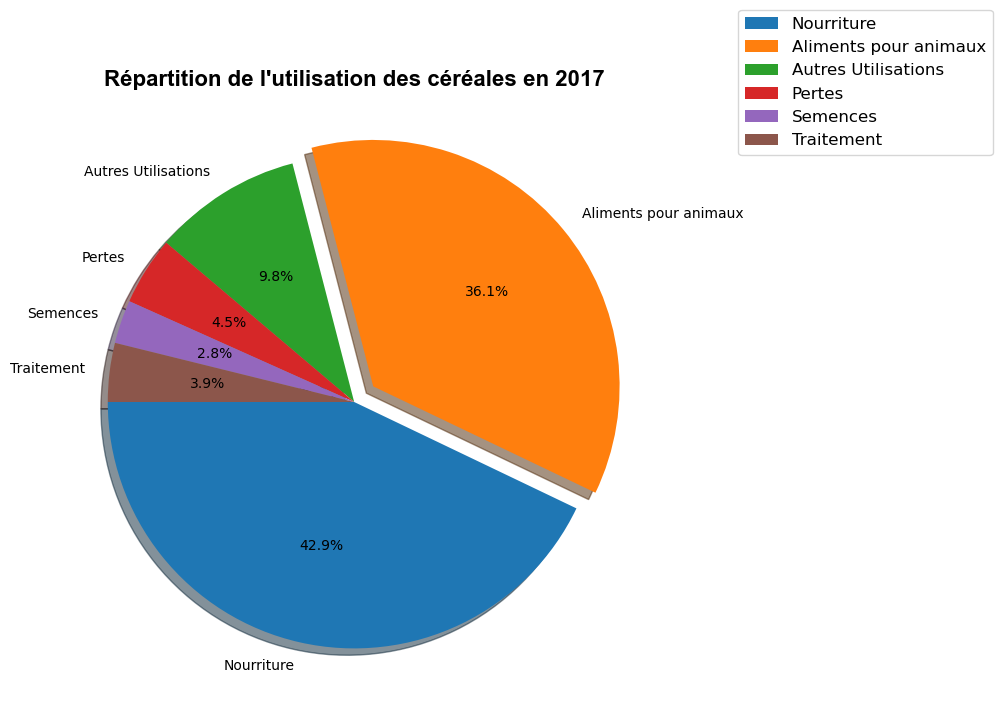

Grâce à ce diagramme circulaire,
on constate que la proportion de céréales utilisées pour l'alimentation animale 
s'élève à 36 % des céréales disponibles en 2017.


In [61]:
#Affichage de la proportion d'alimentation animale
import matplotlib.pyplot as plt
categories = ['Nourriture',
              'Aliments pour animaux', 
              'Autres Utilisations',
              'Pertes',
              'Semences',
              'Traitement']
valeurs = [df_cereales[col].sum() for col in categories]

plt.figure(figsize=(15, 8))
plt.pie(valeurs, labels=categories, autopct='%1.1f%%',
        explode = [0,0.1,0,0,0,0],
        startangle=180, shadow=True)
plt.title("Répartition de l'utilisation des céréales en 2017", fontname='Arial', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor= (1.55,1.15),fontsize='12')
plt.show()

print("Grâce à ce diagramme circulaire,\non constate que la proportion de céréales utilisées pour l'alimentation animale \ns'élève à 36 % des céréales disponibles en 2017.")

<a id="section3_6"></a>

### 3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017


In [63]:
#Création de la colonne proportion par pays
#Cette colonne a déjà été créée plus haut, on affiche le dataframe pour vérifier
df_2017

,Zone,Année_x,Population,Année_y,sous_nutrition,proportion_sous_nutrition
0,Afghanistan,2017,36296113.0,2015-2017,9700000.0,26.72
1,Afrique du Sud,2017,57009756.0,2015-2017,3000000.0,5.26
2,Albanie,2017,2884169.0,2015-2017,100000.0,3.47
3,Algérie,2017,41389189.0,2015-2017,1300000.0,3.14
4,Allemagne,2017,82658409.0,2015-2017,0.0,0.00
...,...,...,...,...,...,...
198,Venezuela (République bolivarienne du),2017,29402484.0,2015-2017,6200000.0,21.09
199,Viet Nam,2017,94600648.0,2015-2017,7100000.0,7.51
200,Yémen,2017,27834819.0,2015-2017,0.0,0.00
201,Zambie,2017,16853599.0,2015-2017,0.0,0.00


In [64]:
#affichage après trie des 10 pires pays
print("Voici le top 10 des pays avec la plus forte proportion de sous-nutrition en 2017.\n")

top10_sous_nutrition = df_2017.sort_values(by="proportion_sous_nutrition", ascending=False).head(10)
top10_sous_nutrition

Voici le top 10 des pays avec la plus forte proportion de sous-nutrition en 2017.



,Zone,Année_x,Population,Année_y,sous_nutrition,proportion_sous_nutrition
78,Haïti,2017,10982366.0,2015-2017,5200000.0,47.35
157,République populaire démocratique de Corée,2017,25429825.0,2015-2017,11600000.0,45.62
108,Madagascar,2017,25570512.0,2015-2017,10300000.0,40.28
103,Libéria,2017,4702226.0,2015-2017,1800000.0,38.28
100,Lesotho,2017,2091534.0,2015-2017,800000.0,38.25
183,Tchad,2017,15016753.0,2015-2017,5300000.0,35.29
161,Rwanda,2017,11980961.0,2015-2017,4100000.0,34.22
186,Timor-Leste,2017,1243258.0,2015-2017,400000.0,32.17
121,Mozambique,2017,28649018.0,2015-2017,9200000.0,32.11
0,Afghanistan,2017,36296113.0,2015-2017,9700000.0,26.72


<a id="section3_7"></a>

### 3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013


In [66]:
#calcul du total de l'aide alimentaire par pays
aide_par_pays = aide_alimentaire.groupby("Zone")["Valeur"].sum().reset_index()
aide_par_pays = aide_par_pays.sort_values("Valeur", ascending=False)
aide_par_pays.head(10)

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


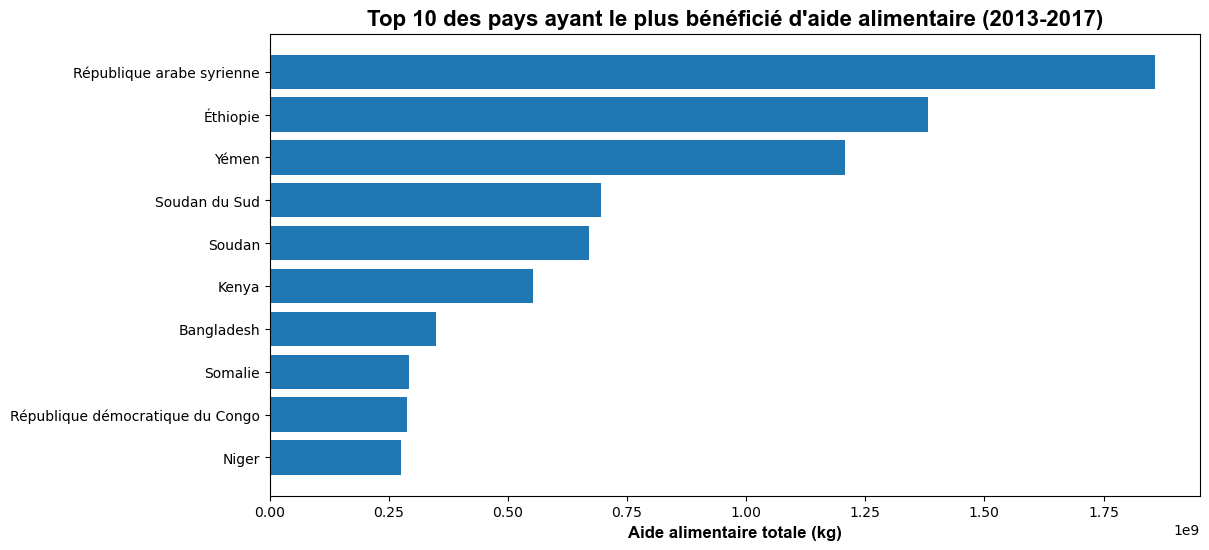

Grâce à ce graphique, on constate que certains pays reçoivent beaucoup plus d'aide alimentaire que les autres.
Cela veut donc dire que l'aide alimentaire mondiale est concentrée sur quelques pays en grande difficulté.


In [67]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
plt.figure(figsize=(12, 6))
plt.barh(aide_par_pays.head(10)["Zone"], aide_par_pays.head(10)["Valeur"])
plt.xlabel("Aide alimentaire totale (kg)",fontsize=12, fontweight='bold',fontname='Arial')
plt.title("Top 10 des pays ayant le plus bénéficié d'aide alimentaire (2013-2017)",fontname='Arial', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print("Grâce à ce graphique, on constate que certains pays reçoivent beaucoup plus d'aide alimentaire que les autres.")
print("Cela veut donc dire que l'aide alimentaire mondiale est concentrée sur quelques pays en grande difficulté.")

<a id="section3_8"></a>

### 3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016


In [69]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aide_par_pays_annee = aide_alimentaire.groupby(["Zone","Année"])["Valeur"].sum().reset_index()
aide_par_pays_annee.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [70]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top5_pays = aide_par_pays.head(5)["Zone"].tolist()
print(f"Les 5 pays ayant le plus bénéficiées de l'aide alimentaire sont :\n {top5_pays}")

Les 5 pays ayant le plus bénéficiées de l'aide alimentaire sont :
 ['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']


In [71]:
#On filtre sur le dataframe avec notre liste
df_top5 = aide_par_pays_annee[aide_par_pays_annee["Zone"].isin(top5_pays)]
df_top5

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


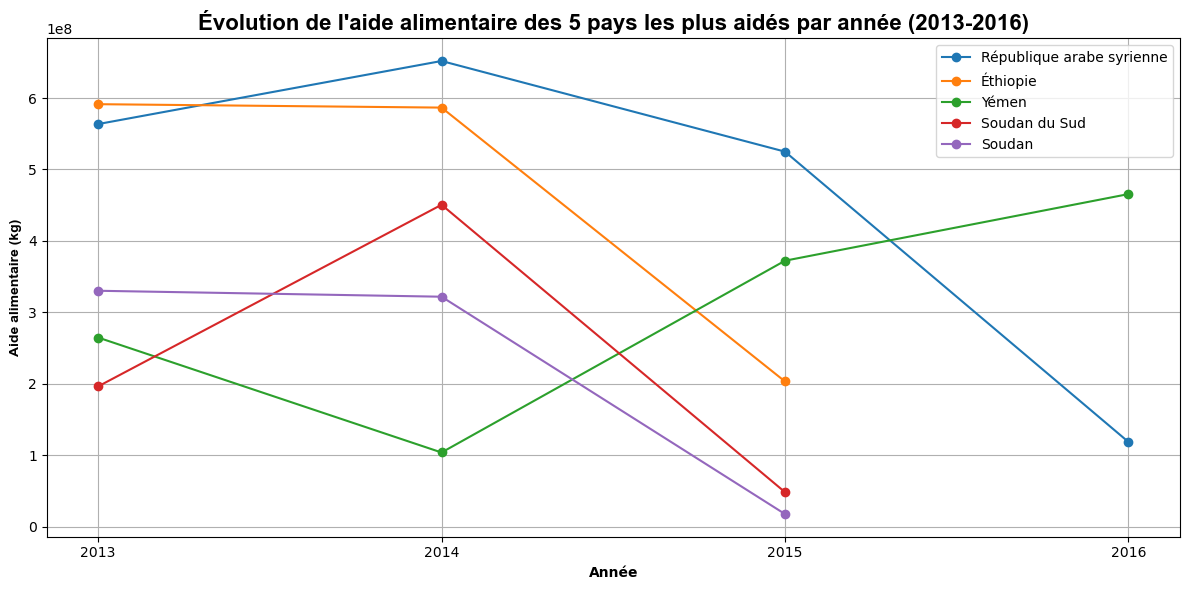

Grâce à ce graphique, on constate que l'aide alimentaire varie beaucoup d'une année à l'autre pour chaque pays.
Cela veut donc dire que l'aide alimentaire dépend de la situation de chaque pays à un moment donné (conflits, sécheresses, crises).


In [72]:
# Affichage des pays avec l'aide alimentaire par année
plt.figure(figsize=(12, 6))
for pays in top5_pays:
    data = df_top5[df_top5["Zone"] == pays]
    plt.plot(data["Année"], data["Valeur"], marker='o', label=pays)

plt.title("Évolution de l'aide alimentaire des 5 pays les plus aidés par année (2013-2016)",fontname='Arial', fontsize=16, fontweight='bold')
plt.xlabel("Année",fontsize=10, fontweight='bold')
plt.xticks([2013, 2014, 2015, 2016,])
plt.ylabel("Aide alimentaire (kg)",fontsize=10, fontweight='bold',fontname='Arial')
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Grâce à ce graphique, on constate que l'aide alimentaire varie beaucoup d'une année à l'autre pour chaque pays.")
print("Cela veut donc dire que l'aide alimentaire dépend de la situation de chaque pays à un moment donné (conflits, sécheresses, crises).")

<a id="section3_9"></a>

### 3.9 - Pays avec le moins de disponibilité par habitant


In [74]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_par_pays = df_pop_dispo_2017.groupby("Zone")["Disponibilité alimentaire (Kcal/personne/jour)"].sum().reset_index()
dispo_par_pays.columns = ["Zone", "Dispo_kcal_par_personne_jour"]
dispo_par_pays.head()

,Zone,Dispo_kcal_par_personne_jour
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


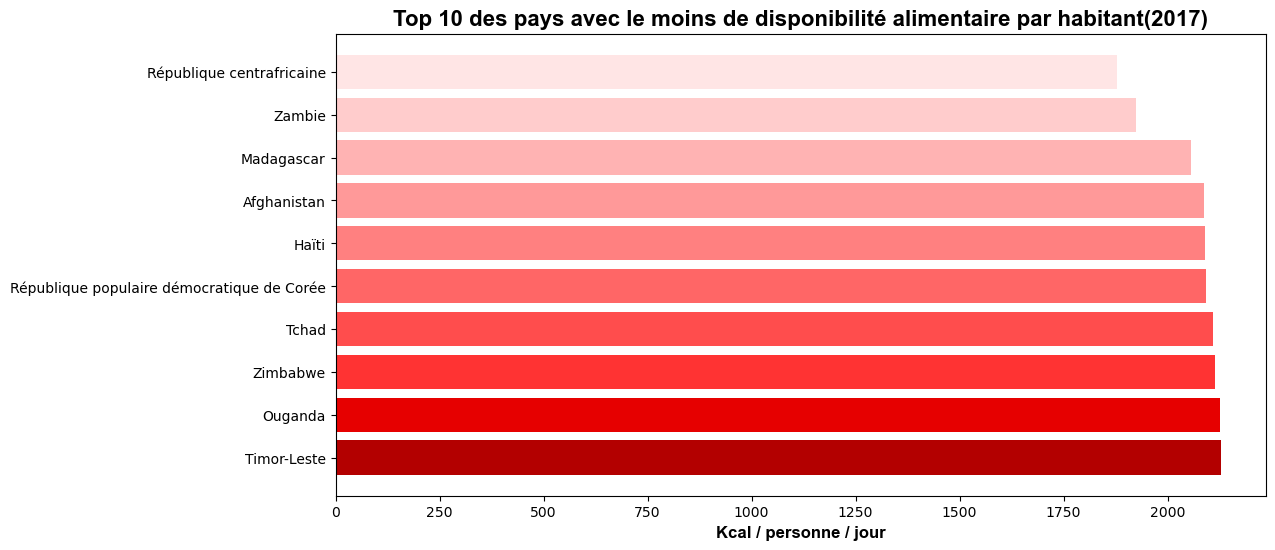

Grâce à ce graphique, on constate que les pays avec le moins de disponibilité alimentaire se trouvent majoritairement en Afrique.
Cela veut donc dire que ces pays n'ont pas assez de nourriture disponible pour couvrir les besoins de leur population.


In [75]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne

top10_moins_kcal = dispo_par_pays.sort_values("Dispo_kcal_par_personne_jour").head(10)

couleurs = [
'#FFE5E5',
'#FFCCCC',
'#FFB3B3',
'#FF9999',
'#FF8080',
'#FF6666',
'#FF4D4D',
'#FF3333',
'#E60000',
'#B30000'
]
plt.figure(figsize=(12, 6))
plt.barh(top10_moins_kcal["Zone"], top10_moins_kcal["Dispo_kcal_par_personne_jour"],color=couleurs)
plt.xlabel("Kcal / personne / jour", fontsize=12, fontweight='bold', fontname='Arial')
plt.title("Top 10 des pays avec le moins de disponibilité alimentaire par habitant(2017)", fontname='Arial', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print("Grâce à ce graphique, on constate que les pays avec le moins de disponibilité alimentaire se trouvent majoritairement en Afrique.")
print("Cela veut donc dire que ces pays n'ont pas assez de nourriture disponible pour couvrir les besoins de leur population.")

<a id="section3_10"></a>

### 3.10 - Pays avec le plus de disponibilité par habitant


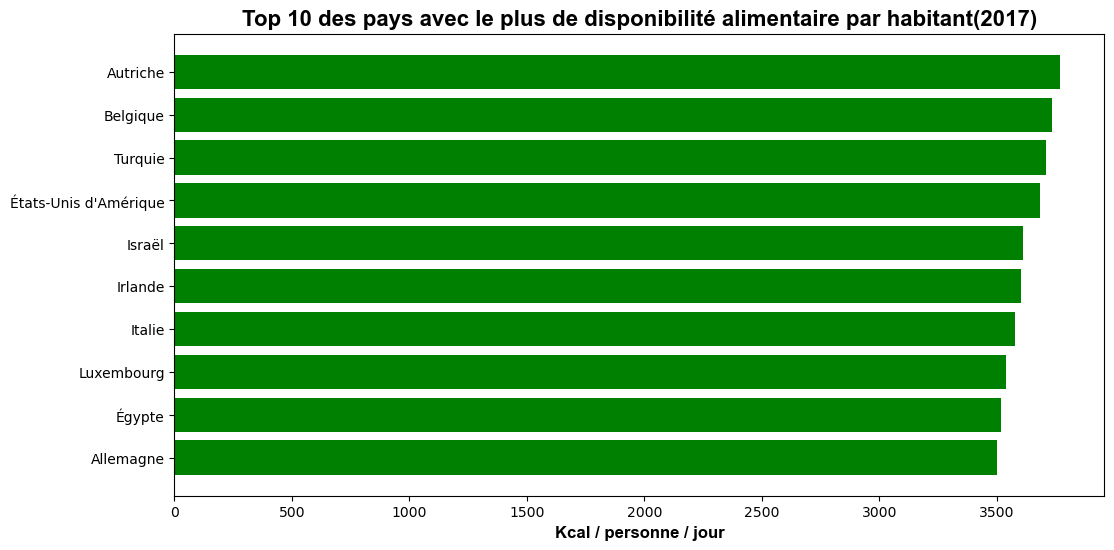

Grâce à ce graphique, on constate que les pays les mieux dotés en disponibilité alimentaire sont des pays développés.
Cela veut donc dire qu'il y a un écart énorme entre les pays les plus riches et les plus pauvres en termes de nourriture disponible.


In [77]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
top10_plus_kcal = dispo_par_pays.sort_values("Dispo_kcal_par_personne_jour",ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10_plus_kcal["Zone"], top10_plus_kcal["Dispo_kcal_par_personne_jour"],color='green')
plt.xlabel("Kcal / personne / jour", fontsize=12, fontweight='bold', fontname='Arial')
plt.title("Top 10 des pays avec le plus de disponibilité alimentaire par habitant(2017)", fontname='Arial', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

print("Grâce à ce graphique, on constate que les pays les mieux dotés en disponibilité alimentaire sont des pays développés.")
print("Cela veut donc dire qu'il y a un écart énorme entre les pays les plus riches et les plus pauvres en termes de nourriture disponible.")

<a id="section3_11"></a>

### 3.11 - Exemple de la Thaïlande pour le Manioc


In [79]:
#création d'un dataframe avec uniquement la Thaïlande 
thailande = df_pop_dispo_2017[df_pop_dispo_2017["Zone"] == "Thaïlande"]
thailande_manioc = thailande[thailande["Produit"] == "Manioc"]
thailande_manioc

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,dispo_kcal
14166,Thaïlande,2017,69209810.0,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,...,6.264000e+09,2.521400e+10,1.250000e+09,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,2.768392e+09


In [80]:
#Calcul de la sous nutrition en Thaïlande
population_thai = population_2017[population_2017["Zone"] =="Thaïlande"]["Population"].values[0]
sous_nutri_thai = sous_nutrition[(sous_nutrition["Zone"] == "Thaïlande") &(sous_nutrition["Année"] == "2015-2017")]["sous_nutrition"].values[0]

print(f"Population Thaïlande en 2017 : {int(population_thai):,}")
print(f"Personnes en sous-nutrition : {int(sous_nutri_thai):,}")
print(f"Proportion : {round(sous_nutri_thai / population_thai * 100, 2)} %")

Population Thaïlande en 2017 : 69,209,810
Personnes en sous-nutrition : 6,000,000
Proportion : 8.67 %


In [81]:
# On calcule la proportion exportée en fonction de la proportion
export_manioc = thailande_manioc["Exportations - Quantité"].values[0]
production_manioc = thailande_manioc["Production"].values[0]
proportion_export = (export_manioc / production_manioc) * 100

print(f"Production de Manioc en Thaïlande : {int(production_manioc):,} kg")
print(f"Exportations de Manioc : {int(export_manioc):,} kg")
print(f"La Thaïlande exporte {round(proportion_export)} % de sa production de Manioc.\n")
print(f"Cela veut donc dire que la Thaïlande utilise le manioc principalement pour l'exportation.")
print(f"Malgré une proportion de sous-nutrition dans le pays, une grande partie de la production est envoyée à l'étranger.")

Production de Manioc en Thaïlande : 30,228,000,000 kg
Exportations de Manioc : 25,214,000,000 kg
La Thaïlande exporte 83 % de sa production de Manioc.

Cela veut donc dire que la Thaïlande utilise le manioc principalement pour l'exportation.
Malgré une proportion de sous-nutrition dans le pays, une grande partie de la production est envoyée à l'étranger.


<a id="etape3"></a>

## 4. Analyses complémentaires


In [83]:
# Importation de Seaborn
import seaborn as sns

<a id="section6_1"></a>

### Disponibilité par continent


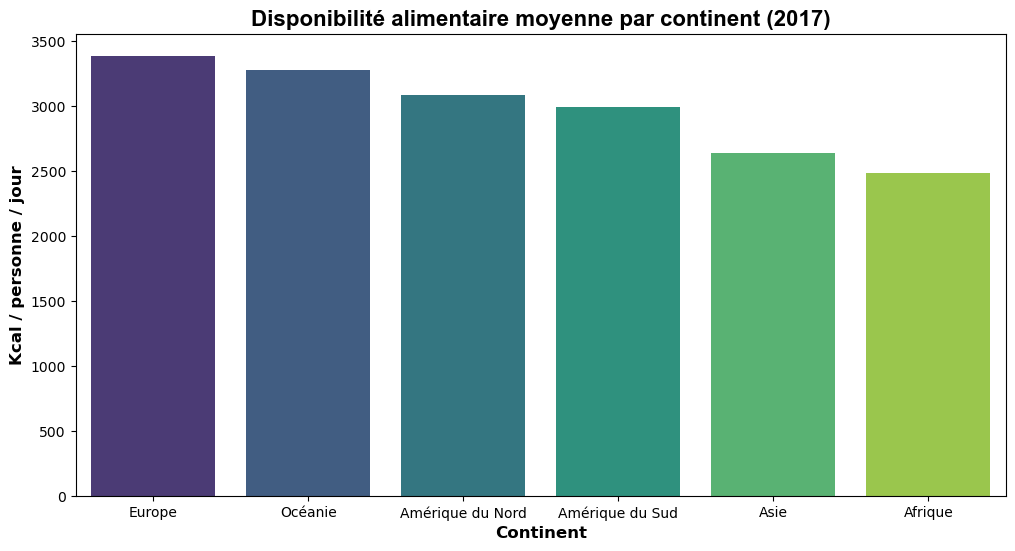

Grâce à ce graphique, on constate que l'Europe et l'Amérique du Nord disposent de la plus forte
disponibilité alimentaire par habitant, tandis que l'Afrique est le continent le moins bien doté.
Cela veut donc dire que les inégalités alimentaires sont avant tout géographiques.


In [85]:
#Création d'un dictionnaire pour associer chaque pays à un continent
continents = {
    "Afghanistan": "Asie", "Albanie": "Europe", "Algérie": "Afrique",
    "Allemagne": "Europe", "Australie": "Océanie", "Bangladesh": "Asie",
    "Brésil": "Amérique du Sud", "Cameroun": "Afrique", "Canada": "Amérique du Nord",
    "Chine": "Asie", "Colombie": "Amérique du Sud", "Égypte": "Afrique",
    "Espagne": "Europe", "France": "Europe", "Haïti": "Amérique du Nord",
    "Inde": "Asie", "Indonésie": "Asie", "Italie": "Europe",
    "Japon": "Asie", "Kenya": "Afrique", "Madagascar": "Afrique",
    "Mexique": "Amérique du Nord", "Mozambique": "Afrique", "Niger": "Afrique",
    "Nigéria": "Afrique", "Pakistan": "Asie", "Pérou": "Amérique du Sud",
    "Rwanda": "Afrique", "Sénégal": "Afrique", "Tchad": "Afrique",
    "Thaïlande": "Asie", "Turquie": "Asie", "Viet Nam": "Asie",
    "Yémen": "Asie", "Zambie": "Afrique", "Zimbabwe": "Afrique",
    "Afrique du Sud": "Afrique", "Argentine": "Amérique du Sud",
    "Éthiopie": "Afrique", "Royaume-Uni": "Europe", "Russie": "Europe",
    "États-Unis d'Amérique": "Amérique du Nord"
}

#Ajout de la colonne continent dans le dataframe dispo_par_pays
dispo_par_pays["Continent"] = dispo_par_pays["Zone"].map(continents)

#On garde uniquement les pays qui ont un continent associé
dispo_continent = dispo_par_pays.dropna(subset=["Continent"])

#Calcul de la moyenne par continent
moyenne_continent = dispo_continent.groupby("Continent")["Dispo_kcal_par_personne_jour"].mean().reset_index()
moyenne_continent = moyenne_continent.sort_values("Dispo_kcal_par_personne_jour", ascending=False)

#Affichage du graphique
plt.figure(figsize=(12, 6))
sns.barplot(data=moyenne_continent, x="Continent", y="Dispo_kcal_par_personne_jour", hue="Continent", palette="viridis", legend=False)
plt.title("Disponibilité alimentaire moyenne par continent (2017)", fontname='Arial', fontsize=16, fontweight='bold')
plt.ylabel("Kcal / personne / jour", fontsize=12, fontweight='bold')
plt.xlabel("Continent", fontsize=12, fontweight='bold')
plt.show()

print(f"Grâce à ce graphique, on constate que l'Europe et l'Amérique du Nord disposent de la plus forte")
print(f"disponibilité alimentaire par habitant, tandis que l'Afrique est le continent le moins bien doté.")
print(f"Cela veut donc dire que les inégalités alimentaires sont avant tout géographiques.")

<a id="section6_2"></a>

### Corrélation disponibilité vs sous-nutrition


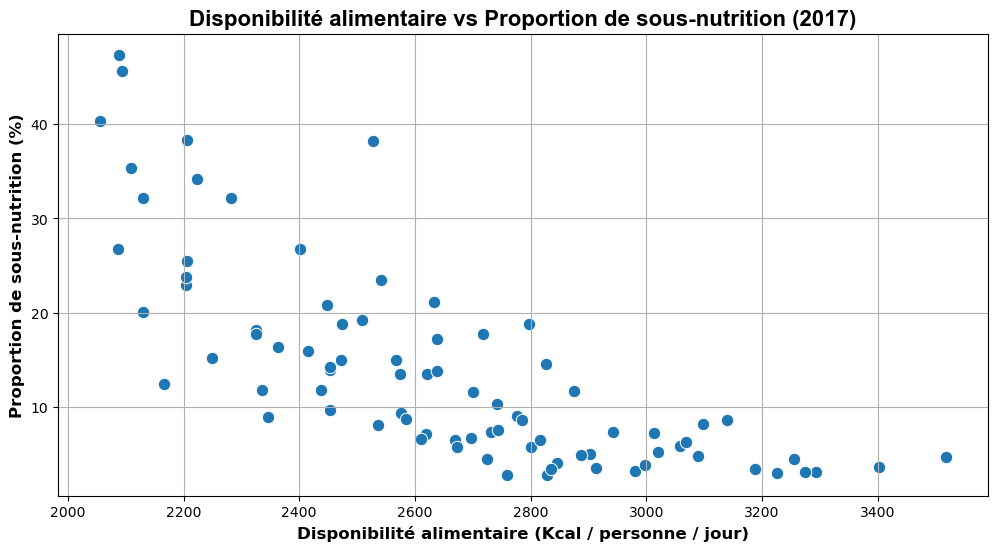

Grâce à ce nuage de points, on constate que plus un pays dispose de kcal par habitant,
moins sa proportion de sous-nutrition est élevée.
Cela veut donc dire qu'il y a bien un lien entre la quantité de nourriture disponible et la faim dans un pays.


In [87]:
#Fusion de la dispo par pays avec la proportion de sous-nutrition
df_analyse = pd.merge(dispo_par_pays, df_2017[["Zone", "proportion_sous_nutrition"]], on="Zone")

#On garde uniquement les pays avec une proportion supérieure à 0
df_analyse_filtre = df_analyse[df_analyse["proportion_sous_nutrition"] > 0]

#Affichage du graphique
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_analyse_filtre, x="Dispo_kcal_par_personne_jour", y="proportion_sous_nutrition", s=80)
plt.title("Disponibilité alimentaire vs Proportion de sous-nutrition (2017)", fontname='Arial', fontsize=16, fontweight='bold')
plt.xlabel("Disponibilité alimentaire (Kcal / personne / jour)", fontsize=12, fontweight='bold')
plt.ylabel("Proportion de sous-nutrition (%)", fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()

print(f"Grâce à ce nuage de points, on constate que plus un pays dispose de kcal par habitant,")
print(f"moins sa proportion de sous-nutrition est élevée.")
print(f"Cela veut donc dire qu'il y a bien un lien entre la quantité de nourriture disponible et la faim dans un pays.")

<a id="section6_3"></a>

### Apport animal vs végétal


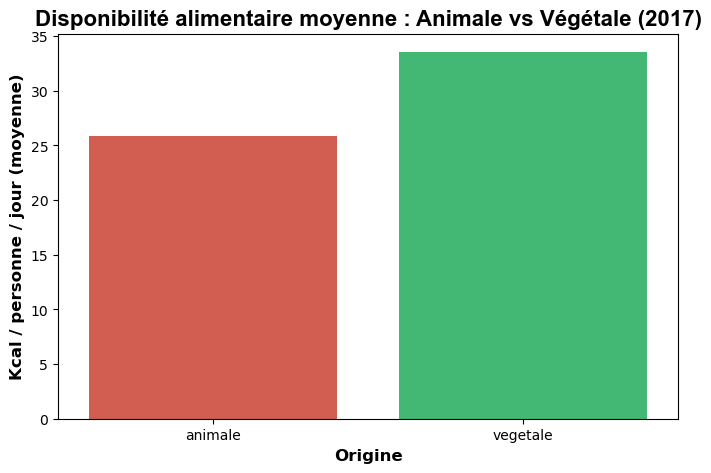

Grâce à ce graphique, on constate que les produits d'origine végétale apportent en moyenne
beaucoup plus de kcal par personne et par jour que les produits d'origine animale.
Cela veut donc dire que l'alimentation mondiale repose majoritairement sur les végétaux.


In [89]:
#Calcul de la disponibilité moyenne en kcal par origine (animale vs végétale)
dispo_par_origine = df_pop_dispo_2017.groupby("Origine")["Disponibilité alimentaire (Kcal/personne/jour)"].mean().reset_index()
dispo_par_origine.columns = ["Origine", "Moyenne_kcal_par_personne_jour"]

#Affichage du graphique
plt.figure(figsize=(8, 5))
sns.barplot(data=dispo_par_origine, x="Origine", y="Moyenne_kcal_par_personne_jour", hue="Origine", palette=["#e74c3c", "#2ecc71"], legend=False)
plt.title("Disponibilité alimentaire moyenne : Animale vs Végétale (2017)", fontname='Arial', fontsize=16, fontweight='bold')
plt.ylabel("Kcal / personne / jour (moyenne)", fontsize=12, fontweight='bold')
plt.xlabel("Origine", fontsize=12, fontweight='bold')
plt.show()

print(f"Grâce à ce graphique, on constate que les produits d'origine végétale apportent en moyenne")
print(f"beaucoup plus de kcal par personne et par jour que les produits d'origine animale.")
print(f"Cela veut donc dire que l'alimentation mondiale repose majoritairement sur les végétaux.")

---

<a id="conclusion"></a>

## 5. Conclusion et recommandations

### 🎯 Synthèse des résultats

Cette analyse des données FAO 2017 révèle une réalité contre-intuitive :

> **Le problème de la faim dans le monde n'est PAS un problème de production, mais de répartition.**

#### 📊 Preuves principales

**1. Production mondiale suffisante**
- Le monde produit assez pour nourrir **7,1 milliards de personnes** (94,3% de la population)
- Même avec uniquement les végétaux, on pourrait nourrir **5,87 milliards** (78%)
- Pourtant, **528 millions de personnes** sont en sous-nutrition (7,01%)

**2. Inefficacité de la chaîne alimentaire**
- Seulement **49,3%** de la production destinée à l'alimentation humaine
- **36,1%** des céréales servent à nourrir les animaux (presque autant que les humains)
- **22,4%** en traitement industriel, **4,6%** en pertes

**3. Problème économique et politique**
- **Paradoxe des exportations :** La Thaïlande exporte 83% de son manioc alors que 8,67% de sa population est sous-alimentée
- **Aide mal ciblée :** L'aide alimentaire va aux zones de conflits (Syrie, Yémen), pas aux pays en sous-nutrition chronique (Haïti 47%, Corée du Nord 46%)
- **Corrélation forte :** Plus un pays a de disponibilité alimentaire, moins il a de sous-nutrition

---

### 📋 Recommandations pour la FAO

#### 🚨 Court terme (0-12 mois)

**1. Rediriger l'aide alimentaire**
- Cibler en priorité les pays avec >35% de sous-nutrition chronique
- Top 3 prioritaires : **Haïti (47,4%), Corée du Nord (45,6%), Madagascar (40,3%)**
- Stabiliser les flux d'aide (actuellement trop irréguliers d'une année à l'autre)

#### 🎯 Moyen terme (1-3 ans)

**2. Politiques d'export responsable**
- Taxer ou limiter les exportations alimentaires depuis les pays >10% de sous-nutrition
- Exemple concret : La Thaïlande devrait réduire ses exports de manioc de 83% à 50%
- Créer des incitations économiques pour nourrir d'abord la population locale

**3. Optimiser la chaîne alimentaire mondiale**
- Réduire l'utilisation des céréales pour l'alimentation animale (de 36% à 25%)
- **Impact :** Libérer assez de nourriture pour nourrir **150 millions de personnes** supplémentaires
- Programme de réduction des pertes post-récolte (actuellement 4,6%)

#### 🌱 Long terme (3-5 ans)

**4. Transition alimentaire mondiale**
- Promouvoir l'alimentation végétale directe (plus efficace énergétiquement)
- Investir dans l'agriculture locale des pays en sous-nutrition
- Formation des agriculteurs aux techniques de conservation et rendement

**5. Surveillance et indicateurs**
- Créer un indicateur "Ratio Export/Sous-nutrition" pour identifier les paradoxes
- Monitoring mensuel de la disponibilité alimentaire des pays à risque
- Système d'alerte précoce basé sur les données de disponibilité

---

### ⚠️ Limites de l'étude

- **Données 2017 :** Analyse ponctuelle, pas d'évolution temporelle sur plusieurs années
- **Agrégation pays :** Masque les inégalités régionales internes (ex: certaines régions d'Inde)
- **Causes profondes :** L'analyse ne couvre pas les facteurs politiques, sociaux et climatiques
- **Données manquantes :** Certains pays non couverts par les datasets FAO

---

### 🚀 Perspectives d'amélioration

Pour approfondir cette analyse, il serait pertinent de :
1. **Analyse temporelle** : Étudier l'évolution 2013-2020 pour identifier les tendances
2. **Granularité régionale** : Analyser au niveau des provinces/états pour cibler les interventions
3. **Modélisation prédictive** : Prédire les zones à risque pour les 3 prochaines années
4. **Intégration multi-sources** : Croiser avec données climatiques, PIB, conflits armés

---

**Auteur :** Helton Dos Santos Moreira | **Contact :** heltonmail8@gmail.com  
**GitHub :** [github.com/Heltondsm](https://github.com/Heltondsm) | **LinkedIn :** [in/helton-dsm-data](https://linkedin.com/in/helton-dsm-data)

**Projet réalisé en mars 2026** | Données : FAO 2017
